# Прогнозируем задержки самолётов


В этом домашнем задании вы будете работать с задачей про задержки самолётов.  На основании доступных данных о рейсе вам нужно определить, будет ли он задержан на 15 минут. 

## Импорт библиотек, установка констант

In [39]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import mlxtend

from mlxtend.evaluate import bias_variance_decomp

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import r2_score, roc_auc_score

In [3]:
RANDOM_STATE = 111
DATASET_PATH = 'https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/flight_delays_train.csv'

## Загрузка и обзор данных

In [4]:
data = pd.read_csv(DATASET_PATH)

In [6]:
data.sample(5)

,Month,DayofMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
6333,c-2,c-27,c-7,1151,UA,ORD,PDX,1739,N
54400,c-5,c-13,c-6,845,WN,BUR,SJC,296,N
10492,c-8,c-23,c-3,1449,AA,DEN,DFW,641,N
79814,c-8,c-24,c-3,1600,EV,CHS,ATL,259,Y
71144,c-7,c-30,c-6,1720,MQ,EVV,ORD,273,N


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Month              100000 non-null  str  
 1   DayofMonth         100000 non-null  str  
 2   DayOfWeek          100000 non-null  str  
 3   DepTime            100000 non-null  int64
 4   UniqueCarrier      100000 non-null  str  
 5   Origin             100000 non-null  str  
 6   Dest               100000 non-null  str  
 7   Distance           100000 non-null  int64
 8   dep_delayed_15min  100000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 6.9 MB


In [17]:
data.describe(include='number')

,DepTime,Distance
count,100000.000000,100000.00000
mean,1341.523880,729.39716
std,476.378445,574.61686
min,1.000000,30.00000
25%,931.000000,317.00000
50%,1330.000000,575.00000
75%,1733.000000,957.00000
max,2534.000000,4962.00000


In [13]:
data.describe(include = 'str')

,Month,DayofMonth,DayOfWeek,UniqueCarrier,Origin,Dest,dep_delayed_15min
count,100000,100000,100000,100000,100000,100000,100000
unique,12,31,7,22,289,289,2
top,c-8,c-1,c-4,WN,ATL,ATL,N
freq,8830,3399,14736,15082,5834,5795,80956


## Вопрос для Quiz

Сколько числовых столбцов в данных?

In [16]:
len(data.select_dtypes(include='number').columns)

2

## Обучение моделей 

Разбейте данные
* на матрицу объект признак `X`, содержащую только числовые столбцы `DepTime`, `Distance`
* вектор с целевой переменной `y`, равный столбцу `dep_delayed_15min`, переведенном в 0 и 1 по правилу: 'Y' - 1, 'N' - 0.

In [27]:
X = data.select_dtypes(include='number')

y = data['dep_delayed_15min'].map({'Y' : 1, 'N' : 0})
# y = data['dep_delayed_15min'].apply(lambda x: 1 if x == 'Y' else 0) - еще так можно

Обучите по кросс-валидации с тремя фолдами и метрикой *ROC-AUC* (`scoring='roc_auc'`) три модели с гиперпараметрами по умолчанию:
* решающее дерево
* случайный лес 
* градиентный бустинг

Выведите на экран среднее качество по кросс-валидации каждой из моделей.

In [32]:
%%time

dt = DecisionTreeClassifier()

cross_val_score(dt, X, y, cv = 3, scoring = 'roc_auc').mean()

CPU times: total: 562 ms
Wall time: 564 ms


np.float64(0.5790515297042363)

In [34]:
%%time

rf = RandomForestClassifier()

cross_val_score(rf, X, y, cv = 3, scoring = 'roc_auc').mean()

CPU times: total: 23.5 s
Wall time: 23.5 s


np.float64(0.6749850487428247)

In [35]:
%%time

gb = GradientBoostingClassifier()

cross_val_score(gb, X, y, cv = 3, scoring = 'roc_auc').mean()

CPU times: total: 9.3 s
Wall time: 9.3 s


np.float64(0.6992478321854853)

## Вопрос для Quiz

какой алгоритм показал наилучшее качество? `GB`

Выведите *bias* и *variance* каждой из моделей при помощи `bias_variance_decomp` из библиотеки `mlxtend`. Функция на вход ожидает получения тренировочных и тестовых данных, поэтому разобъем все данные на train и test.

Для ускорения вычислений 
* возьмите только первые 1000 строк из тренировочных данных (`Xtrain[:1000], ytrain[:1000]`)
* поставьте `num_rounds = 50` в функции `bias_variance_decomp`

И не забудьте перевести `pd.dataframe` в `np.array` - так как библиотека умеет работать только с этим типом данных (`Xtrain.values` и так для всех объектов).

In [38]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

In [42]:
Xtr = Xtrain[:1000].values
ytr = ytrain[:1000].values
Xtest = Xtest.values
ytest = ytest.values

In [50]:
avg_mse, avg_bias, avg_var = bias_variance_decomp(DecisionTreeClassifier(), Xtr, ytr, Xtest, ytest, loss='0-1_loss',
                                                  num_rounds = 50, random_seed=np.random.seed(RANDOM_STATE))

print('Loss of Decision Tree:    ', avg_mse)
print('Bias of Decision Tree:    ', avg_bias)
print('Variance of Decision Tree:', avg_var)

Loss of Decision Tree:     0.29694319999999996
Bias of Decision Tree:     0.24816
Variance of Decision Tree: 0.17137840000000001


In [48]:
avg_mse, avg_bias, avg_var = bias_variance_decomp(RandomForestClassifier(), Xtr, ytr, Xtest, ytest, loss='0-1_loss',
                                                  num_rounds = 50, random_seed=np.random.seed(RANDOM_STATE))

print('Loss of Random Forest:    ', avg_mse)
print('Bias of Random Forest:    ', avg_bias)
print('Variance of Random Forest:', avg_var)

Loss of Random Forest:     0.2465008
Bias of Random Forest:     0.22756
Variance of Random Forest: 0.08974560000000001


In [49]:
avg_mse, avg_bias, avg_var = bias_variance_decomp(GradientBoostingClassifier(), Xtr, ytr, Xtest, ytest, loss='0-1_loss',
                                                  num_rounds = 50, random_seed=np.random.seed(RANDOM_STATE))

print('Loss of Gradient Boosting:    ', avg_mse)
print('Bias of Gradient Boosting:    ', avg_bias)
print('Variance of Gradient Boosting:', avg_var)

Loss of Gradient Boosting:     0.2166288
Bias of Gradient Boosting:     0.19976
Variance of Gradient Boosting: 0.062118400000000004



## Вопрос для Quiz

какой алгоритм с гиперпараметрами по умолчанию имеет наименьшее смещение? `GB`

## Подбор гиперпараметров

Напомним, как мы действуем при подборе гиперпараметров:
* разбиваем данные на *train* и *test*
* на train по кросс-валидации при помощи `GridSearchCV` ищем наилучшие гиперпараметры модели
* оцениваем качество модели с наилучшими гиперпараметрами на *test*

Будем использовать 3 фолда при кросс-валидации, а метрику - *ROC-AUC* (`scoring='roc_auc'`).


Далее везде можно обучать модель на первых 10000 строк из обучающей выборки (так как всего два признака).

### 1. Подберите гиперпараметры для решающего дерева:
* `max_depth` (обязательно) - max глубина дерева
* `max_features` (обязательно) - max # признаков, исп-мых для поиска предиката в каждой вершине
* `criterion` (по желанию) - критерий для выбора предиката
* `min_samples_split` (по желанию) - min # объектов в вершине, чтобы ее дальше разбивать
* `min_samples_leaf` (по желанию) - min # объектов в листе => если в вершине < объектов, чем min_samples_leaf, то разбиение не производится

Диапазоны поиска гиперпараметров выбирайте самостоятельно.

Добейтесь качества *ROC-AUC* $>0.65$ на кросс-валидации.

In [51]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

In [111]:
Xtrain_gs = Xtrain.iloc[:10000]
ytrain_gs = ytrain.iloc[:10000]

param_grid = {
    'max_depth': range(2, 11),
    'max_features': [1, 2],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(Xtrain_gs, ytrain_gs)

Fitting 3 folds for each of 576 candidates, totalling 1728 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=111)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': range(2, 11), 'max_features': [1, 2], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [112]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC на CV:", grid_search.best_score_)

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 4, 'max_features': 2, 'min_samples_leaf': 5, 'min_samples_split': 2}
Лучший ROC-AUC на CV: 0.6928825659420045


Теперь обучите на **всех** тренировочных данных решающее дерево с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [113]:
best_tree = grid_search.best_estimator_

best_tree.fit(Xtrain, ytrain)

pred = best_tree.predict_proba(Xtest)[:,1]

roc_auc_score(ytest, pred)

0.6956885102638536

### 2. Подберите гиперпараметры для случайного леса:
* `n_estimators` (обязательно)
* `max_depth` (обязательно)
* `max_features` (по желанию)
* `criterion` (по желанию)
* `min_samples_split` (по желанию)
* `min_samples_leaf` (по желанию)

Диапазоны поиска гиперпараметров выбирайте самостоятельно.

Добейтесь качества *ROC-AUC* $>0.65$ на кросс-валидации.

In [114]:
param_grid = {
    'n_estimators' : np.arange(50, 200, 50),
    'max_depth': range(2, 11),
    'max_features': [1, 2],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(Xtrain_gs, ytrain_gs)

Fitting 3 folds for each of 1728 candidates, totalling 5184 fits


KeyboardInterrupt: 

In [98]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC на CV:", grid_search.best_score_)

Лучшие параметры: {'criterion': 'gini', 'max_depth': 4, 'max_features': 2, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': np.int64(100)}
Лучший ROC-AUC на CV: 0.7005143687793902


In [115]:
best_rf = RandomForestClassifier(
    criterion = 'gini',
    max_depth = 4, 
    max_features = 2, 
    min_samples_leaf = 10, 
    min_samples_split = 2, 
    n_estimators = 100
)

best_rf.fit(Xtrain, ytrain)

pred = best_rf.predict_proba(Xtest)[:,1]

roc_auc_score(ytest, pred)

0.7005401703749751

### Код от Ромы:

In [71]:
import optuna

In [80]:
from tqdm.autonotebook import tqdm

In [81]:
X_sample = Xtrain
y_sample = ytrain

def objective(trial):
    # Предлагаем значения гиперпараметров в заданных диапазонах
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 190, step=20),
        'max_depth': trial.suggest_int('max_depth', 2, 10),  # верхняя граница включительно? в np.arange(2,10) это 2..9, так что тут 9
        'max_features': trial.suggest_int('max_features', 1, 3),  # шаг 1 по умолчанию
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5)
    }
    
    # Создаём модель
    model = RandomForestClassifier(**params, random_state=42)
    
    # Оцениваем качество с помощью кросс-валидации (cv=3, как в GridSearchCV)
    scores = cross_val_score(model, X_sample, y_sample, cv=3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Создаём исследование (study) – максимизируем ROC-AUC
study = optuna.create_study(direction='maximize', study_name='rf_optimization')
# Запускаем оптимизацию. n_trials можно выбрать любое, например 100 (аналог количества комбинаций)
n_trials = 100
with tqdm(total=n_trials, desc='Optuna', position=0, leave=True) as pbar:
    def callback(study, trial):
        pbar.update(1)
        pbar.set_postfix(best=study.best_value)
    study.optimize(objective, n_trials=n_trials, callbacks=[callback])



[I 2026-03-12 19:19:41,981] A new study created in memory with name: rf_optimization
[I 2026-03-12 19:19:44,557] Trial 0 finished with value: 0.6950586922632529 and parameters: {'n_estimators': 10, 'max_depth': 8, 'max_features': 2, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.6950586922632529.
[I 2026-03-12 19:19:47,897] Trial 1 finished with value: 0.6913520984574978 and parameters: {'n_estimators': 110, 'max_depth': 3, 'max_features': 1, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.6950586922632529.
[I 2026-03-12 19:19:49,962] Trial 2 finished with value: 0.695977155846388 and parameters: {'n_estimators': 10, 'max_depth': 10, 'max_features': 1, 'criterion': 'gini', 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.695977155846388.
[I 2026-03-12 19:19:54,134] Trial 3 finished with value: 0.6872151129711104 and parameters: {'n_estimators': 170, 

In [83]:
# Лучшие параметры
print("Best trial:")
print(study.best_trial.params)
print("Best ROC-AUC:", study.best_trial.value)

Best trial:
{'n_estimators': 190, 'max_depth': 10, 'max_features': 1, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 1}
Best ROC-AUC: 0.7006277952583672


In [84]:
best_rf = RandomForestClassifier(**study.best_trial.params, random_state=42)
best_rf.fit(X_sample, y_sample)

pred = best_rf.predict(Xtest)

roc_auc_score(ytest, pred)

0.5261285642565671

In [ ]:
tree = gs.best_estimator_

tree.fit(Xtrain, ytrain)

pred = tree.predict(Xtest)

roc_auc_score(ytest, pred)

In [61]:
gs.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",np.int64(50)
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",np.int64(6)
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with s

In [62]:
cross_val_score(gs.best_estimator_, Xtest, ytest, cv = 3, scoring = 'roc_auc').mean()

np.float64(0.7015559747365833)

### 3. Подберите гиперпараметры для градиентного бустинга:
* `n_estimators` (обязательно)
* `max_depth` (обязательно)
* `max_features` (по желанию)
* `criterion` (по желанию)
* `min_samples_split` (по желанию)
* `min_samples_leaf` (по желанию)

Диапазоны поиска гиперпараметров выбирайте самостоятельно.

Добейтесь качества *ROC-AUC* $>0.65$ на кросс-валидации.

In [117]:
param_grid = {
    'n_estimators' : np.arange(10, 70, 20),
    'max_depth': np.arange(2, 20, 3),
    'max_features': [1, 2],
    'criterion': ['friedman_mse', 'squared_error'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(Xtrain_gs, ytrain_gs)

Fitting 3 folds for each of 648 candidates, totalling 1944 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...dom_state=111)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['friedman_mse', 'squared_error'], 'max_depth': array([ 2, 5..., 11, 14, 17]), 'max_features': [1, 2], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computat

In [118]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC на CV:", grid_search.best_score_)

Лучшие параметры: {'criterion': 'friedman_mse', 'max_depth': np.int64(2), 'max_features': 2, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': np.int64(30)}
Лучший ROC-AUC на CV: 0.6995077433872007


In [120]:
best_gb = GradientBoostingClassifier(
    criterion = 'friedman_mse', 
    max_depth = 2, 
    max_features = 2, 
    min_samples_leaf = 2, 
    min_samples_split = 5, 
    n_estimators = 30)

best_gb.fit(Xtrain, ytrain)

pred = best_gb.predict_proba(Xtest)[:,1]

roc_auc_score(ytest, pred)

0.6997204913343631

Теперь поставьте `learning_rate = 0.01` (в десять раз меньше, чем по умолчанию) и увеличьте найденное число деревьев в 10 раз.

С этими изменениями обучите бустинг на трейне и выведите качество на тесте.

In [121]:
best_gb = GradientBoostingClassifier(
    criterion = 'friedman_mse', 
    max_depth = 2, 
    max_features = 2, 
    min_samples_leaf = 2, 
    min_samples_split = 5, 
    n_estimators = 300,
    learning_rate = 0.01)

best_gb.fit(Xtrain, ytrain)

pred = best_gb.predict_proba(Xtest)[:,1]

roc_auc_score(ytest, pred)

0.6996940808521006

Зачем это делают обычно?

- Маленький `learning_rate` + много деревьев позволяет модели обучаться медленнее, аккуратнее подстраиваясь под данные, и часто даёт лучшее качество на сложных задачах.

- Это также помогает бороться с переобучением: большое число деревьев с малым шагом менее склонны «запоминать» шум.

В вашем эксперименте эффект не проявился, потому что задача проста. Тем не менее, такой подход стоит всегда проверять при настройке бустинга. Если бы качество упало, это могло бы указывать на переобучение исходной модели, а если бы выросло – значит, исходная модель была недообучена.

# Улучшение модели

Мы выкинули очень много колонок из начальной таблицы, но, возможно, они полезны для наших моделей.

Попробуем улучшить модель, использовав другие признаки.

In [122]:
data['dep_delayed_15min'] = data['dep_delayed_15min'].map({'Y' : 1, 'N' : 0})

Обработаем колонку месяц, оставив в ней только число - номер месяца.

Посмотрим на среднее количество задержек в каждом месяце.

In [126]:
data['Month'] = data['Month'].apply(lambda x: int(x.split('-')[1]))

print('average:', data['dep_delayed_15min'].mean())

data.groupby('Month')['dep_delayed_15min'].mean()

average: 0.19044


Month
1     0.190588
2     0.177406
3     0.194997
4     0.155328
5     0.153693
6     0.221892
7     0.238112
8     0.201925
9     0.156683
10    0.178584
11    0.170824
12    0.241258
Name: dep_delayed_15min, dtype: float64

Мы видим, что в некоторые месяцы (7 и 12) задержек довольно много, а в какие-то месяцы наоборот меньше. Так что признак может пригодиться!

В данных также есть интересный признак `UniqueCarrier` - это код авиакомпании-перевозчика. 

Давайте посмотрим, связаны ли как-то задержки самолетов с авиакомпанией. Для этого выведем среднее число задержек и количество рейсов по каждой авиакомпании.

In [127]:
print('average:', data['dep_delayed_15min'].mean())

data.groupby('UniqueCarrier').agg({"dep_delayed_15min": ["mean", "count"]})

average: 0.19044


dep_delayed_15min       
                           mean  count
UniqueCarrier                         
AA                     0.187938   9418
AQ                     0.076923    234
AS                     0.243474   2222
B6                     0.213819   1838
CO                     0.181818   4334
DH                     0.161491    966
DL                     0.168922   8128
EV                     0.275318   3930
F9                     0.155070   1006
FL                     0.242185   3039
HA                     0.043307    762
HP                     0.142235   1378
MQ                     0.194545   7443
NW                     0.167890   6403
OH                     0.175882   4594
OO                     0.172801   7390
TZ                     0.143498    446
UA                     0.192263   6876
US                     0.167387   6482
WN                     0.213433  15082
XE                     0.173869   5901
YV                     0.224624   2128

Мы видим, что некоторые перевозчики довольно часто задерживают рейсы, а некоторые почти не задерживают. То есть знание об авиакомпании важно!

Закодируем столбец `UniqueCarrier` при помощи `OneHot encoding`. В pandas этот метод называется `get_dummies`.

In [152]:
X = data[['Month','UniqueCarrier','DepTime','Distance']]
y = data['dep_delayed_15min']

X = pd.get_dummies(X, columns=['UniqueCarrier'], drop_first=True) # drop_first=True - выкидываем один столбец, чтобы избежать линейной зависимости
X = X.astype(int)
X.head()

,Month,DepTime,Distance,UniqueCarrier_AQ,UniqueCarrier_AS,UniqueCarrier_B6,UniqueCarrier_CO,UniqueCarrier_DH,UniqueCarrier_DL,UniqueCarrier_EV,...,UniqueCarrier_MQ,UniqueCarrier_NW,UniqueCarrier_OH,UniqueCarrier_OO,UniqueCarrier_TZ,UniqueCarrier_UA,UniqueCarrier_US,UniqueCarrier_WN,UniqueCarrier_XE,UniqueCarrier_YV
0,8,1934,732,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,1548,834,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,9,1422,416,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,11,1015,872,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,10,1828,423,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [153]:
print('Decision Tree:', cross_val_score(DecisionTreeClassifier(), X, y, cv=3, scoring='roc_auc').mean())
print('Random Forest:', cross_val_score(RandomForestClassifier(), X, y, cv=3, scoring='roc_auc').mean())
print('Gradient Boosting:', cross_val_score(GradientBoostingClassifier(), X, y, cv=3, scoring='roc_auc').mean())

Decision Tree: 0.5816902828362629
Random Forest: 0.6949432768116336
Gradient Boosting: 0.7129765912830512


In [154]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

Базовые модели показывают результаты по кросс-валидации чуть лучше! Ура!

Теперь вам необходимо подобрать оптимальные гиперпараметры модели так же, как вы делали в заданиях выше.

Так как информации о каждой авиакомпании не так много, то здесь для обучения лучше использовать все тренировочные данные, а не только первые 10000 строк.

### Подберите оптимальные гиперпараметры для `Decision Tree`.

In [155]:
param_grid = {
    'max_depth': range(2, 11),
    'max_features': np.arange(1, 4),
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(Xtrain, ytrain)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC на CV:", grid_search.best_score_)

Fitting 3 folds for each of 864 candidates, totalling 2592 fits
Лучшие параметры: {'criterion': 'gini', 'max_depth': 10, 'max_features': np.int64(2), 'min_samples_leaf': 5, 'min_samples_split': 2}
Лучший ROC-AUC на CV: 0.6813366519492116


Теперь обучите на **всех** тренировочных данных случайный лес с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [156]:
best_tree = grid_search.best_estimator_

best_tree.fit(Xtrain, ytrain)

pred = best_tree.predict_proba(Xtest)[:,1]

roc_auc_score(ytest, pred)

0.6821765395319102

### Подберите оптимальные гиперпараметры для `Random Forest`.

In [157]:
param_grid = {
    'n_estimators' : np.arange(50, 200, 50),
    'max_depth': np.arange(2, 30, 2)
    #'max_features': [1, 2],
    #'criterion': ['gini', 'entropy'],
    #'min_samples_split': [2, 5, 10, 20],
    #'min_samples_leaf': [1, 2, 5, 10]
}

rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(Xtrain, ytrain)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC на CV:", grid_search.best_score_)

Fitting 3 folds for each of 42 candidates, totalling 126 fits
Лучшие параметры: {'max_depth': np.int64(16), 'n_estimators': np.int64(150)}
Лучший ROC-AUC на CV: 0.7153196993699941


Теперь обучите на **всех** тренировочных данных случайный лес с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [158]:
best_rf = grid_search.best_estimator_

best_rf.fit(Xtrain, ytrain)

pred = best_rf.predict_proba(Xtest)[:,1]

roc_auc_score(ytest, pred)

0.7185596681258171

### Подберите оптимальные гиперпараметры для `Gradient Boosting`.

In [163]:
param_grid = {
    'n_estimators' : [70],
    'max_depth': np.arange(4, 20, 3),
    'max_features': [1, 2, 3, 4],
    #'criterion': ['friedman_mse', 'squared_error'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(Xtrain, ytrain)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC на CV:", grid_search.best_score_)

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Лучшие параметры: {'max_depth': np.int64(7), 'max_features': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 70}
Лучший ROC-AUC на CV: 0.7155608289000238


Теперь обучите на **всех** тренировочных данных случайный лес с лучшими  
найденными гиперпараметрами и выведите *ROC-AUC* на тесте.

In [160]:
best_gb = grid_search.best_estimator_

best_gb.fit(Xtrain, ytrain)

pred = best_gb.predict_proba(Xtest)[:,1]

roc_auc_score(ytest, pred)

0.7202931875969582

In [161]:
print("Число признаков в модели:", len(best_gb.feature_importances_))
print("Число столбцов в Xtrain:", Xtrain.shape[1])

Число признаков в модели: 24
Число столбцов в Xtrain: 24


Посмотрим на важность признаков у полученного бустинга.

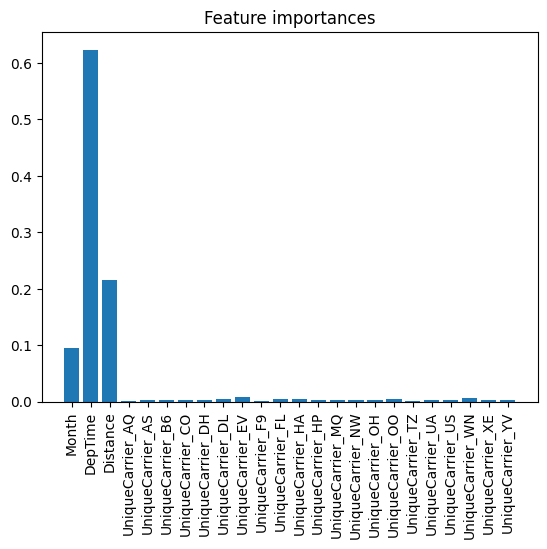

In [162]:
# в коде model - это модель (если назвали по-другому, то в этом кусочке измените model на свое название)

importances = best_gb.feature_importances_
indices = np.argsort(importances)

plt.figure()
plt.title("Feature importances")
plt.bar(range(len(best_gb.feature_importances_)), best_gb.feature_importances_)
plt.xticks(range(len(best_gb.feature_importances_)), X.columns, rotation='vertical')
plt.show()